Imports

In [1]:

import matplotlib.pyplot as plt

from src.synthetic_data import generate_base_data
from src.models import least_squares_fit, ridge_fit, predict, mean_squared_error

Experiment settings

In [2]:
n_train = 100
n_test = 1000
max_d = 300
d_true = 10
noise_std = 0.5
alpha = 1e-1

d_values = [5, 10, 20, 40, 60, 80, 90, 95, 99,
            100, 101, 105, 110, 120, 150, 200, 250, 300]

Generating the dataset

In [3]:
X_train_full, y_train, X_test_full, y_test, w_star = generate_base_data(
    n_train=n_train,
    n_test=n_test,
    max_d=max_d,
    d_true=d_true,
    noise_std=noise_std,
    seed=42
)

print(X_train_full.shape)
print(X_test_full.shape)
print(y_train.shape)
print(y_test.shape)

(100, 300)
(1000, 300)
(100,)
(1000,)


Running least squares and ridge

In [4]:
ls_train_errors = []
ls_test_errors = []

ridge_train_errors = []
ridge_test_errors = []

for d in d_values:
    X_train = X_train_full[:, :d]
    X_test = X_test_full[:, :d]

    # Least squares
    w_ls = least_squares_fit(X_train, y_train)

    y_train_pred_ls = predict(X_train, w_ls)
    y_test_pred_ls = predict(X_test, w_ls)

    ls_train_mse = mean_squared_error(y_train, y_train_pred_ls)
    ls_test_mse = mean_squared_error(y_test, y_test_pred_ls)

    ls_train_errors.append(ls_train_mse)
    ls_test_errors.append(ls_test_mse)

    # Ridge regression
    w_ridge = ridge_fit(X_train, y_train, alpha=alpha)

    y_train_pred_ridge = predict(X_train, w_ridge)
    y_test_pred_ridge = predict(X_test, w_ridge)

    ridge_train_mse = mean_squared_error(y_train, y_train_pred_ridge)
    ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

    ridge_train_errors.append(ridge_train_mse)
    ridge_test_errors.append(ridge_test_mse)

least squares plot

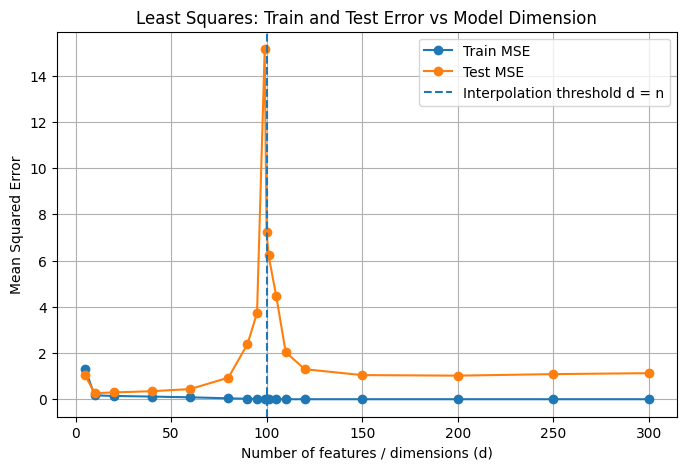

In [5]:
plt.style.use("default")

plt.figure(figsize=(8, 5), facecolor="white")

plt.plot(d_values, ls_train_errors, marker="o", label="Train MSE")
plt.plot(d_values, ls_test_errors, marker="o", label="Test MSE")

plt.axvline(n_train, linestyle="--", label="Interpolation threshold d = n")

plt.xlabel("Number of features / dimensions (d)")
plt.ylabel("Mean Squared Error")
plt.title("Least Squares: Train and Test Error vs Model Dimension")
plt.legend()
plt.grid(True)

plt.show()

Ridge plot

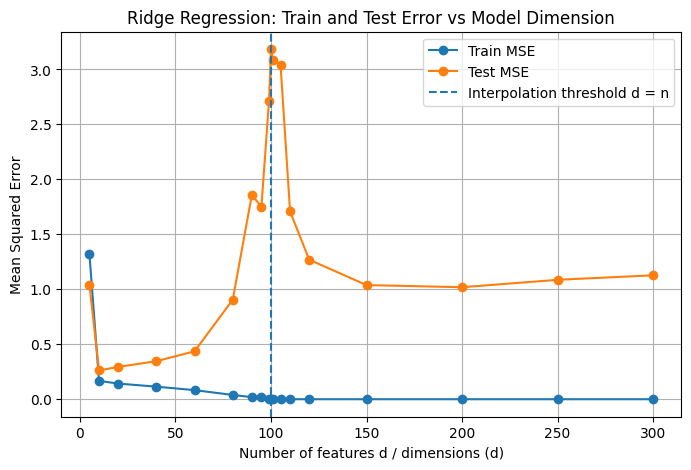

In [6]:
plt.figure(figsize=(8, 5), facecolor="white")

plt.plot(d_values, ridge_train_errors, marker="o", label="Train MSE")
plt.plot(d_values, ridge_test_errors, marker="o", label="Test MSE")

plt.axvline(n_train, linestyle="--", label="Interpolation threshold d = n")

plt.xlabel("Number of features d / dimensions (d)")
plt.ylabel("Mean Squared Error")
plt.title("Ridge Regression: Train and Test Error vs Model Dimension")
plt.legend()
plt.grid(True)

plt.show()

Least squares vs ridge comparison plot

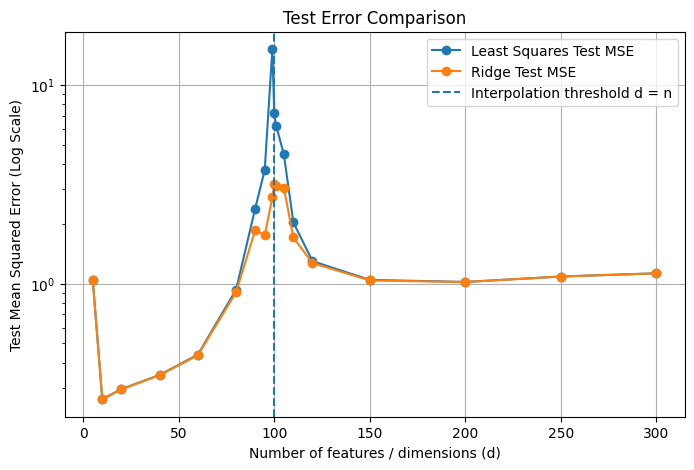

In [7]:
plt.figure(figsize=(8, 5), facecolor="white")

plt.plot(d_values, ls_test_errors, marker="o", label="Least Squares Test MSE")
plt.plot(d_values, ridge_test_errors, marker="o", label="Ridge Test MSE")

plt.axvline(n_train, linestyle="--", label="Interpolation threshold d = n")

plt.xlabel("Number of features / dimensions (d)")
plt.ylabel("Test Mean Squared Error (Log Scale)")
plt.title("Test Error Comparison")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

Printed numerical results

In [8]:
for i, d in enumerate(d_values):
    print(
        f"d={d:3d} | "
        f"LS train={ls_train_errors[i]:.4f}, LS test={ls_test_errors[i]:.4f} | "
        f"Ridge train={ridge_train_errors[i]:.4f}, Ridge test={ridge_test_errors[i]:.4f}"
    )

d=  5 | LS train=1.3173, LS test=1.0412 | Ridge train=1.3173, Ridge test=1.0411
d= 10 | LS train=0.1667, LS test=0.2624 | Ridge train=0.1667, Ridge test=0.2619
d= 20 | LS train=0.1425, LS test=0.2945 | Ridge train=0.1425, Ridge test=0.2938
d= 40 | LS train=0.1142, LS test=0.3471 | Ridge train=0.1142, Ridge test=0.3459
d= 60 | LS train=0.0827, LS test=0.4390 | Ridge train=0.0827, Ridge test=0.4360
d= 80 | LS train=0.0389, LS test=0.9321 | Ridge train=0.0389, Ridge test=0.9051
d= 90 | LS train=0.0186, LS test=2.3870 | Ridge train=0.0189, Ridge test=1.8589
d= 95 | LS train=0.0151, LS test=3.7302 | Ridge train=0.0157, Ridge test=1.7503
d= 99 | LS train=0.0029, LS test=15.1449 | Ridge train=0.0058, Ridge test=2.7171
d=100 | LS train=0.0000, LS test=7.2208 | Ridge train=0.0014, Ridge test=3.1837
d=101 | LS train=0.0000, LS test=6.2336 | Ridge train=0.0012, Ridge test=3.0861
d=105 | LS train=0.0000, LS test=4.4836 | Ridge train=0.0007, Ridge test=3.0438
d=110 | LS train=0.0000, LS test=2.0343